In [1]:
#importación de librerias
import numpy as np
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype
import warnings
from sklearn import tree
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.naive_bayes import BernoulliNB
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFE
import itertools


import time
from sklearn.linear_model import LogisticRegression
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold


warnings.filterwarnings("ignore")

In [2]:
# Definir la ruta base de los archivos de datos
base_dir = r"/home/daniel/Desktop/TFG/nsl-kdd"

# Definir las rutas completas de los archivos de entrenamiento y prueba
train_path = os.path.join(base_dir, "KDDTrain+.txt")
test_path = os.path.join(base_dir, "KDDTest+.txt")

# Nombres de las columnas
column_names = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins",
    "logged_in", "num_compromised", "root_shell", "su_attempted", "num_root",
    "num_file_creations", "num_shells", "num_access_files", "num_outbound_cmds",
    "is_host_login", "is_guest_login", "count", "srv_count", "serror_rate",
    "srv_serror_rate", "rerror_rate", "srv_rerror_rate", "same_srv_rate",
    "diff_srv_rate", "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty"
]

# Cargar los datos en dataframes
train = pd.read_csv(train_path, names=column_names)
test = pd.read_csv(test_path, names=column_names)

# Añadir la columna 'class': 0 para normal, 1 para anomalía
train['class'] = train['label'].apply(lambda x: 0 if x == 'normal' else 1)
test['class'] = test['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Mostrar las primeras líneas del dataframe de entrenamientotrain.head()
train.head()


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21,0


In [3]:
train.info() #Información sobre el dataframe de entrenamiento

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13 

In [4]:
train.describe() #Driscripciones del dataframe de entrenamiento para columnas numéricas


,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty,class
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060,0.465417
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503,0.498805
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000,1.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000,1.000000


In [5]:
train.describe(include='object') #Descripciones del dataframe de entrenamiento para columnas categóricas

,protocol_type,service,flag,label
count,125973,125973,125973,125973
unique,3,70,11,23
top,tcp,http,SF,normal
freq,102689,40338,74945,67343


In [6]:
train.shape #Tamaño del dataframe de entrenamiento

(125973, 44)

In [7]:
train.isnull().sum() #Contar el numero de valores nulos en cada columan del dataframe de entrenamiento

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [8]:
print(f"Número de filas duplicadas: {train.duplicated().sum()}") #Imprimir el número de filas duplicadas en el dataframe de entrenamiento

Número de filas duplicadas: 0


class
0    67343
1    58630
Name: count, dtype: int64


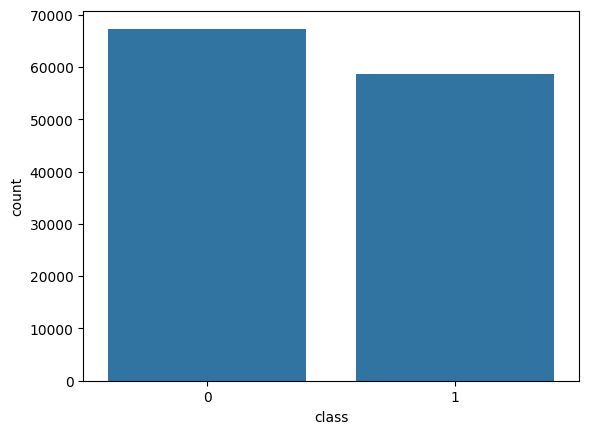

In [9]:
#visualiza la distribución de la variable objetivo ('class') en el dataframe de entrenamiento
sns.countplot(x=train['class'])
print(train['class'].value_counts())

In [10]:
columns_to_drop = ['difficulty', 'num_outbound_cmds']
train.drop(columns=columns_to_drop, axis=1, inplace=True)
test.drop(columns=columns_to_drop, axis=1, inplace=True)


train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,0
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,0
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,1
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,0
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,0


In [11]:
def cod(df):
    for col in df.columns:
        if df[col].dtype == 'object': #Búsqueda de variables categóricas
            label_encoder = LabelEncoder() #Conversor de variables categóricas a variables numéricas
            df[col] = label_encoder.fit_transform(df[col])

cod(train)
cod(test)

In [12]:

print(test.columns)
print(train.columns)

Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell',
       'su_attempted', 'num_root', 'num_file_creations', 'num_shells',
       'num_access_files', 'is_host_login', 'is_guest_login', 'count',
       'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
       'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
       'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
       'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
       'dst_host_serror_rate', 'dst_host_srv_serror_rate',
       'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'class'],
      dtype='object')
Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot',
       'num_failed_logins', 'logged_i

In [13]:
from sklearn.feature_selection import SelectKBest, f_classif
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

# Separar las características (X) y la variable objetivo (Y)
X_train = train.drop(['class', 'label'], axis=1)
Y_train = train['class']
X_test = test.drop(['class', 'label'], axis=1)
Y_test = test['class']

#balanceamos los datos
X_train, Y_train = smote.fit_resample(X_train, Y_train)

# Inicializar el selector SelectKBest con la función ANOVA F-score para clasificación
selector = SelectKBest(score_func=f_classif, k=25)  # Seleccionar las 25 mejores características

# Ajustar el selector a los datos de entrenamiento
selector.fit(X_train, Y_train)

# Obtener las características seleccionadas
selected_mask = selector.get_support()  # Booleano para cada columna
featureMap = [(i, v) for i, v in zip(selected_mask, X_train.columns)]
selectFeatures = [v for i, v in featureMap if i]

print(selectFeatures)


# In[14]:


X_train = X_train[selectFeatures] #Filtrar el dataframe de entrenamiento para incluir solo las caractrísticas seleccionadas
X_test = X_test[selectFeatures]

['duration', 'protocol_type', 'service', 'flag', 'wrong_fragment', 'logged_in', 'is_guest_login', 'count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [14]:
scale = StandardScaler() #inicializar un escaaldor estándar para estandarizar datos
#Aplicar el escalador a los daros de entrenamiento y prueba
X_train = scale.fit_transform(X_train)
X_test = scale.transform(X_test)




In [15]:
X_train.shape

(134686, 25)

In [16]:
RANDOM_STATE = 42 
CV_FOLDS = 5
skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


RANDOM FOREST

In [17]:
startEx=time.time()
def optimizar_rf(trial):
    """
    Función objetivo para Optuna que optimiza los hiperparámetros de RandomForestClassifier
    usando validación cruzada estratificada con puntuación F1.
    """
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 25),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'class_weight': 'balanced',
        'random_state': RANDOM_STATE
    }

    modelo = RandomForestClassifier(**params, n_jobs=-1)
    scores = cross_val_score(modelo, X_train, Y_train, cv=skf, scoring='f1_macro', n_jobs= -1)
    return scores.mean()

# Búsqueda de hiperparámetros con Optuna
study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(optimizar_rf, n_trials=30, n_jobs= -1)

best_params = study_rf.best_params
best_params['random_state'] = RANDOM_STATE


# Entrenamiento final del modelo con mejores parámetros
RF_model = RandomForestClassifier(**best_params,  n_jobs= -1)

start_train = time.time()
RF_model.fit(X_train, Y_train)
end_train = time.time()

print(f"⏱ Tiempo de entrenamiento: {end_train - start_train:.4f} segundos")

# Predicción en test
start_test = time.time()
rf_prob = RF_model.predict_proba(X_test)[:, 1]  # probabilidad clase positiva
threshold = 0.3  # más bajo que 0.5 para subir recall
rf_pred = (rf_prob >= threshold).astype(int)
end_test = time.time()
print(f"⏱ Tiempo de testeo: {end_test - start_test:.4f} segundos")

# Evaluación rigurosa
print(f"\n✅ F1-score Random Forest en test: {f1_score(Y_test, rf_pred):.4f}")
print(f"✅ Accuracy Random Forest en test: {accuracy_score(Y_test, rf_pred):.4f}")
print("\n📊 Reporte de clasificación Random Forest:\n", classification_report(Y_test, rf_pred))
endEx=time.time()
print(f"+++++++Tiempo de Ejecución: {endEx - startEx:.4f} segundos+++++++++")


⏱ Tiempo de entrenamiento: 6.6890 segundos
⏱ Tiempo de testeo: 0.2483 segundos

✅ F1-score Random Forest en test: 0.8181
✅ Accuracy Random Forest en test: 0.8204

📊 Reporte de clasificación Random Forest:
               precision    recall  f1-score   support

           0       0.72      0.97      0.82      9711
           1       0.97      0.71      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544

+++++++Tiempo de Ejecución: 1350.6024 segundos+++++++++


REGRESIÓN LOGÍSTICA

In [18]:
startEx=time.time()
def optimizar_lr(trial):
    
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2', 'elasticnet'])
    C = trial.suggest_loguniform('C', 0.01, 100)
    
    if penalty == 'l1':
        solver = 'liblinear'
    elif penalty == 'l2':
        solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear'])
    else:  # elasticnet
        solver = 'saga'
    
    params = {
        'penalty': penalty,
        'C': C,
        'solver': solver,
        'max_iter': 1000,
        'random_state': RANDOM_STATE
    }
    
    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_uniform('l1_ratio', 0.1, 0.9)
    
    try:
        modelo = LogisticRegression(**params, n_jobs= -1)
        scores = cross_val_score(modelo, X_train, Y_train, cv=skf, scoring='f1_macro', n_jobs= -1)
        return scores.mean()
    except:
        return 0.0

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(optimizar_lr, n_trials=30, n_jobs= -1)
print(study_lr.best_trial)


FrozenTrial(number=1, state=TrialState.COMPLETE, values=[0.9539391270127157], datetime_start=datetime.datetime(2025, 10, 17, 16, 8, 39, 191730), datetime_complete=datetime.datetime(2025, 10, 17, 16, 8, 45, 568425), params={'penalty': 'l2', 'C': 0.010763771481278736, 'solver': 'liblinear'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'penalty': CategoricalDistribution(choices=('l1', 'l2', 'elasticnet')), 'C': FloatDistribution(high=100.0, log=True, low=0.01, step=None), 'solver': CategoricalDistribution(choices=('lbfgs', 'liblinear'))}, trial_id=1, value=None)


In [19]:
best_params = study_lr.best_params.copy()

penalty = best_params['penalty']

# Asignar solver válido según penalty
if penalty == 'l1':
    solver = 'liblinear'
elif penalty == 'l2':
    solver = best_params.get('solver', 'lbfgs')  # Default en caso de que no esté
else:  # elasticnet
    solver = 'saga'
    best_params['l1_ratio'] = best_params.get('l1_ratio', 0.5)  # asegurarse de que exista

# Armar parámetros válidos
final_params = {
    'penalty': penalty,
    'C': best_params['C'],
    'solver': solver,
    'max_iter': 1000,
    'random_state': RANDOM_STATE
}

if penalty == 'elasticnet':
    final_params['l1_ratio'] = best_params['l1_ratio']

# Entrenar modelo
LR_model = LogisticRegression(**final_params, n_jobs= -1)
startTime = time.time()
LR_model.fit(X_train, Y_train)
endTime = time.time()
print(f"⏱ Tiempo de entrenamiento: {end_train - start_train:.4f} segundos")

# Predicción en test
start_test = time.time()
lr_prob = LR_model.predict_proba(X_test)[:, 1]
threshold = 0.3
lr_pred = (lr_prob >= threshold).astype(int)
end_test = time.time()
print(f"⏱ Tiempo de testeo: {end_test - start_test:.4f} segundos")

# Evaluación rigurosa
print(f"\n✅ F1-score Logistic Regression en test: {f1_score(Y_test, lr_pred):.4f}")
print(f"✅ Accuracy Logistic Regression en test: {accuracy_score(Y_test, lr_pred):.4f}")
print("\n📊 Reporte de clasificación Logistic Regression:\n", classification_report(Y_test, lr_pred))
endEx=time.time()
print(f"+++++++Tiempo de Ejecución: {endEx - startEx:.4f} segundos+++++++++")

⏱ Tiempo de entrenamiento: 6.6890 segundos
⏱ Tiempo de testeo: 0.0130 segundos

✅ F1-score Logistic Regression en test: 0.7913
✅ Accuracy Logistic Regression en test: 0.7918

📊 Reporte de clasificación Logistic Regression:
               precision    recall  f1-score   support

           0       0.69      0.92      0.79      9711
           1       0.92      0.69      0.79     12833

    accuracy                           0.79     22544
   macro avg       0.81      0.81      0.79     22544
weighted avg       0.82      0.79      0.79     22544

+++++++Tiempo de Ejecución: 267.8747 segundos+++++++++


K-NEAREST NEIGHBORS

In [20]:
startEx=time.time()
def optimizar_knn(trial):
    """KNN simple pero efectivo para NSL-KDD"""
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 20),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'algorithm': trial.suggest_categorical('algorithm', ['auto', 'ball_tree', 'kd_tree'])
    }
    
    modelo = KNeighborsClassifier(**params, n_jobs= -1)
    scores = cross_val_score(modelo, X_train, Y_train, cv=skf, scoring='f1_macro', n_jobs= -1)
    return scores.mean()

#Un estudio en optuna es un contenedor que permite gestionar múltiples trials
#Permite almacenar y gestionar los resultador de cada uno, facilitando la búsqueda de la mejor configuración de hiperparámetros
study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(optimizar_knn, n_trials=30, n_jobs= -1)
print(study_knn.best_trial)


KNN_model = KNeighborsClassifier(**study_knn.best_params)


#Tiempo de entrenamiento
startTime = time.time()
KNN_model.fit(X_train, Y_train)
endTime = time.time()
print(f"⏱ Tiempo de entrenamiento: {end_train - start_train:.4f} segundos")

# Tiempo de testeo
startTime = time.time()
knn_prob = KNN_model.predict_proba(X_test)[:, 1]
threshold = 0.3
knn_pred = (knn_prob >= threshold).astype(int)
endTime = time.time()
print(f"⏱ Tiempo de testeo: {end_test - start_test:.4f} segundos")


FrozenTrial(number=22, state=TrialState.COMPLETE, values=[0.9953818510214472], datetime_start=datetime.datetime(2025, 10, 17, 16, 28, 12, 67722), datetime_complete=datetime.datetime(2025, 10, 17, 16, 37, 58, 94850), params={'n_neighbors': 3, 'weights': 'distance', 'algorithm': 'auto'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_neighbors': IntDistribution(high=20, log=False, low=3, step=1), 'weights': CategoricalDistribution(choices=('uniform', 'distance')), 'algorithm': CategoricalDistribution(choices=('auto', 'ball_tree', 'kd_tree'))}, trial_id=22, value=None)
⏱ Tiempo de entrenamiento: 6.6890 segundos
⏱ Tiempo de testeo: 0.0130 segundos


In [21]:

print(f"\n✅ F1-score KNN en test: {f1_score(Y_test, knn_pred):.4f}")
print(f"✅ Accuracy KNN en test: {accuracy_score(Y_test, knn_pred):.4f}")
print("\n📊 Reporte de clasificación KNN:\n", classification_report(Y_test, knn_pred))
endEx=time.time()
print(f"+++++++Tiempo de Ejecución: {endEx - startEx:.4f} segundos+++++++++")


✅ F1-score KNN en test: 0.7902
✅ Accuracy KNN en test: 0.7984

📊 Reporte de clasificación KNN:
               precision    recall  f1-score   support

           0       0.69      0.97      0.81      9711
           1       0.97      0.67      0.79     12833

    accuracy                           0.80     22544
   macro avg       0.83      0.82      0.80     22544
weighted avg       0.85      0.80      0.80     22544

+++++++Tiempo de Ejecución: 1788.3381 segundos+++++++++


PERCEPTRÓN MULTICAPA

In [22]:
startEx=time.time()
from sklearn.neural_network import MLPClassifier
def optimizar_mlp(trial):
    hidden_layer_sizes = trial.suggest_categorical('hidden_layer_sizes', [(50,), (100,), (100, 50), (100, 100)])
    activation = trial.suggest_categorical('activation', ['tanh', 'relu'])
    solver = trial.suggest_categorical('solver', ['adam', 'sgd'])
    alpha = trial.suggest_loguniform('alpha', 1e-5, 1e-1)
    learning_rate = trial.suggest_categorical('learning_rate', ['constant', 'adaptive'])

    params = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': activation,
        'solver': solver,
        'alpha': alpha,
        'learning_rate': learning_rate,
        'max_iter': 300,
        'random_state': RANDOM_STATE
    }

    model = MLPClassifier(**params)
    scores = cross_val_score(model, X_train, Y_train, cv=skf, scoring='f1_macro', n_jobs= -1)
    return scores.mean()

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(optimizar_mlp, n_trials=30, n_jobs= -1)
print(study_mlp.best_trial)


FrozenTrial(number=0, state=TrialState.COMPLETE, values=[0.9954560957606912], datetime_start=datetime.datetime(2025, 10, 17, 16, 42, 55, 427350), datetime_complete=datetime.datetime(2025, 10, 17, 16, 51, 19, 942748), params={'hidden_layer_sizes': (100, 100), 'activation': 'tanh', 'solver': 'adam', 'alpha': 6.096317594815154e-05, 'learning_rate': 'adaptive'}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'hidden_layer_sizes': CategoricalDistribution(choices=((50,), (100,), (100, 50), (100, 100))), 'activation': CategoricalDistribution(choices=('tanh', 'relu')), 'solver': CategoricalDistribution(choices=('adam', 'sgd')), 'alpha': FloatDistribution(high=0.1, log=True, low=1e-05, step=None), 'learning_rate': CategoricalDistribution(choices=('constant', 'adaptive'))}, trial_id=0, value=None)


In [23]:
MLP_model = MLPClassifier(**study_mlp.best_params)

# Entrenamiento
startTime = time.time()
MLP_model.fit(X_train, Y_train)
endTime = time.time()
print(f"⏱ Tiempo de entrenamiento: {end_train - start_train:.4f} segundos")


# Testeo
startTime = time.time()
mlp_prob = MLP_model.predict_proba(X_test)[:, 1]
threshold = 0.3
mlp_pred = (mlp_prob >= threshold).astype(int)
endTime = time.time()
print(f"⏱ Tiempo de testeo: {end_test - start_test:.4f} segundos")


print(f"\n✅ F1-score MLP en test: {f1_score(Y_test, mlp_pred):.4f}")
print(f"✅ Accuracy MLP en test: {accuracy_score(Y_test, mlp_pred):.4f}")
print("\n📊 Reporte de clasificación MLP:\n", classification_report(Y_test, mlp_pred))
endEx=time.time()
print(f"+++++++Tiempo de Ejecución: {endEx - startEx:.4f} segundos+++++++++")

⏱ Tiempo de entrenamiento: 6.6890 segundos
⏱ Tiempo de testeo: 0.0130 segundos

✅ F1-score MLP en test: 0.8036
✅ Accuracy MLP en test: 0.8099

📊 Reporte de clasificación MLP:
               precision    recall  f1-score   support

           0       0.70      0.98      0.82      9711
           1       0.98      0.68      0.80     12833

    accuracy                           0.81     22544
   macro avg       0.84      0.83      0.81     22544
weighted avg       0.86      0.81      0.81     22544

+++++++Tiempo de Ejecución: 4049.2567 segundos+++++++++


SVM

In [24]:
startEx=time.time()
def optimizar_svm(trial):
    
    C = trial.suggest_loguniform('C', 0.1, 100)
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf'])
    
    params = {
        'C': C,
        'kernel': kernel,
        'random_state': RANDOM_STATE
    }
    
    if kernel == 'rbf':
        params['gamma'] = trial.suggest_categorical('gamma', ['scale', 'auto'])
    
    try:
        modelo = SVC(**params, n_jobs= -1)
        scores = cross_val_score(modelo, X_train, Y_train, cv=skf, scoring='f1_macro')
        return scores.mean()
    except:
        return 0.0

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(optimizar_svm, n_trials=30, n_jobs= -1)


In [25]:
SVM_model = SVC(**study_svm.best_params, probability=True)

# Medir tiempo de entrenamiento
startTime = time.time()
SVM_model.fit(X_train, Y_train)
endTime = time.time()
print(f"⏱ Tiempo de entrenamiento: {end_train - start_train:.4f} segundos")
# Medir tiempo de testeo
startTime = time.time()
svm_prob = SVM_model.predict_proba(X_test)[:, 1]
threshold = 0.3
svm_pred = (svm_prob >= threshold).astype(int)
endTime = time.time()
print(f"⏱ Tiempo de testeo: {end_test - start_test:.4f} segundos")
print(f"\n✅ F1-score SVM en test: {f1_score(Y_test, svm_pred):.4f}")
print(f"✅ Accuracy SVM en test: {accuracy_score(Y_test, svm_pred):.4f}")
print("\n📊 Reporte de clasificación SVM:\n", classification_report(Y_test, svm_pred))
endEx=time.time()
print(f"+++++++Tiempo de Ejecución: {endEx - startEx:.4f} segundos+++++++++")

⏱ Tiempo de entrenamiento: 6.6890 segundos
⏱ Tiempo de testeo: 0.0130 segundos

✅ F1-score SVM en test: 0.8180
✅ Accuracy SVM en test: 0.8214

📊 Reporte de clasificación SVM:
               precision    recall  f1-score   support

           0       0.71      0.97      0.82      9711
           1       0.97      0.71      0.82     12833

    accuracy                           0.82     22544
   macro avg       0.84      0.84      0.82     22544
weighted avg       0.86      0.82      0.82     22544

+++++++Tiempo de Ejecución: 604.9903 segundos+++++++++


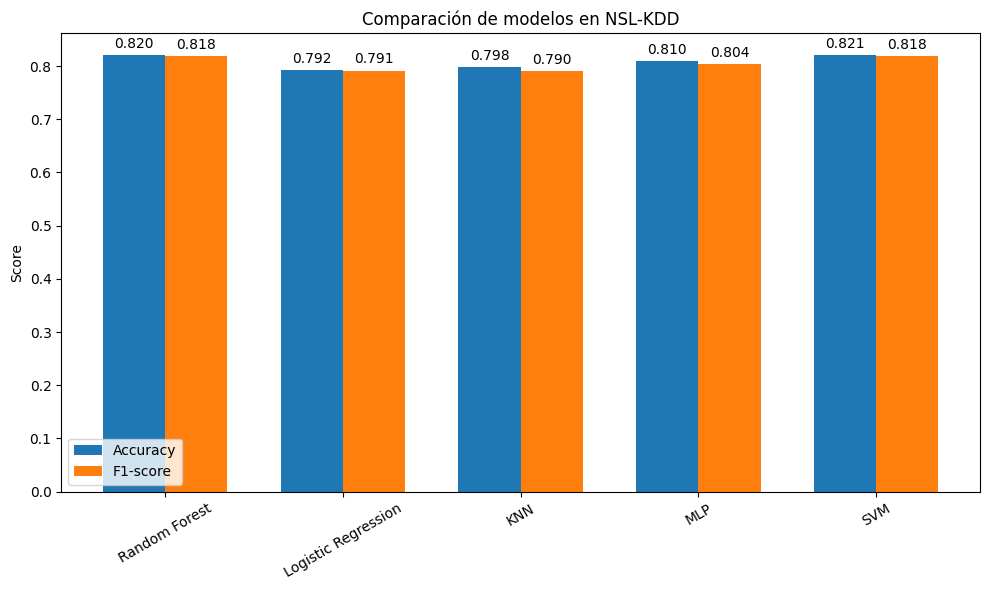

In [26]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

rf_p = precision_score(Y_test, rf_pred, average='weighted')
lr_p = precision_score(Y_test, lr_pred, average='weighted')
knn_p = precision_score(Y_test, knn_pred, average='weighted')
mlp_p = precision_score(Y_test, mlp_pred, average='weighted')
svm_p = precision_score(Y_test, svm_pred, average='weighted')

rf_r = recall_score(Y_test, rf_pred, average='weighted')
lr_r = recall_score(Y_test, lr_pred, average='weighted')
knn_r = recall_score(Y_test, knn_pred, average='weighted')
mlp_r = recall_score(Y_test, mlp_pred, average='weighted')
svm_r = recall_score(Y_test, svm_pred, average='weighted')


rf_a = accuracy_score(Y_test, rf_pred)
lr_a = accuracy_score(Y_test, lr_pred)
knn_a =  accuracy_score(Y_test, knn_pred)
mlp_a = accuracy_score(Y_test, mlp_pred)
svm_a = accuracy_score(Y_test, svm_pred)

rf_f1 = f1_score(Y_test, rf_pred)
lr_f1 = f1_score(Y_test, lr_pred)
knn_f1 = f1_score(Y_test, knn_pred)
mlp_f1 = f1_score(Y_test, mlp_pred)
svm_f1 = f1_score(Y_test, svm_pred)

model_names = ["Random Forest", "Logistic Regression", "KNN", "MLP", "SVM"]

accuracies = [
    rf_a,
    lr_a,
    knn_a,
    mlp_a,
    svm_a
]
f1_scores = [
    rf_f1,
    lr_f1,
    knn_f1,
    mlp_f1,
    svm_f1
]

# 3. Visualiza los resultados en un gráfico de barras
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-score')

ax.set_ylabel('Score')
ax.set_title('Comparación de modelos en NSL-KDD')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30)
ax.legend()

# Etiquetas sobre las baSrras
for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), 
                textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

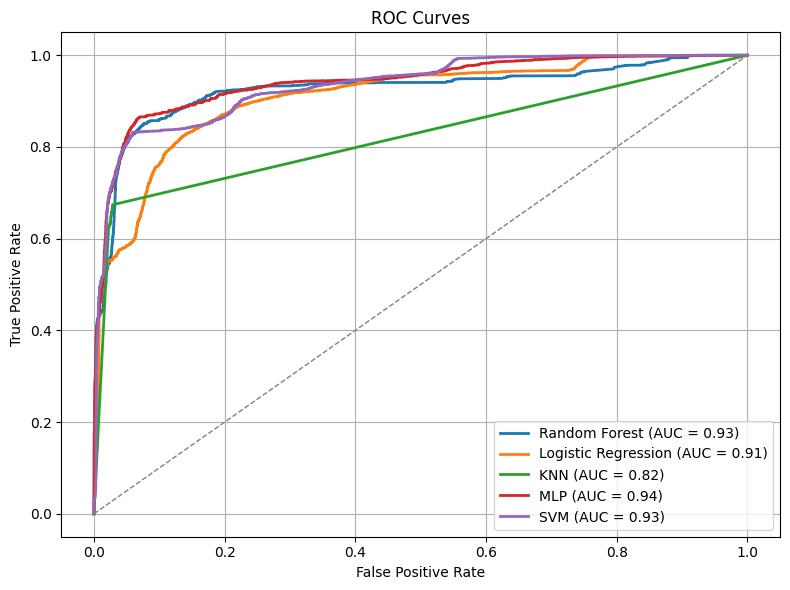

In [27]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))
for name, model, pred in zip(model_names, [RF_model, LR_model, KNN_model, MLP_model, SVM_model],
                             [rf_pred, lr_pred, knn_pred, mlp_pred, svm_pred]):
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        try:
            y_score = model.decision_function(X_test)
        except:
            continue
    fpr, tpr, _ = roc_curve(Y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

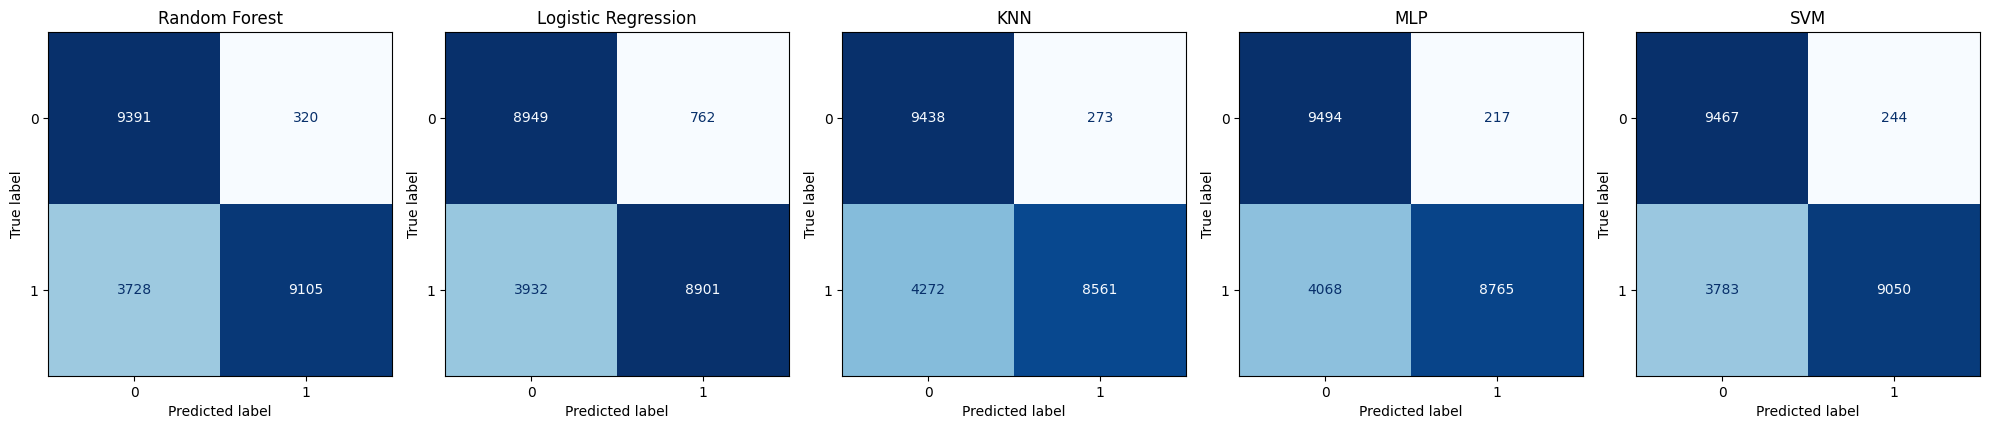

In [28]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for idx, (name, pred) in enumerate(zip(model_names, [rf_pred, lr_pred, knn_pred, mlp_pred, svm_pred])):
    ConfusionMatrixDisplay.from_predictions(
        Y_test,
        pred,
        ax=axes[idx],
        colorbar=False,
        cmap="Blues"  
    )
    axes[idx].set_title(name)

plt.tight_layout()
plt.show()


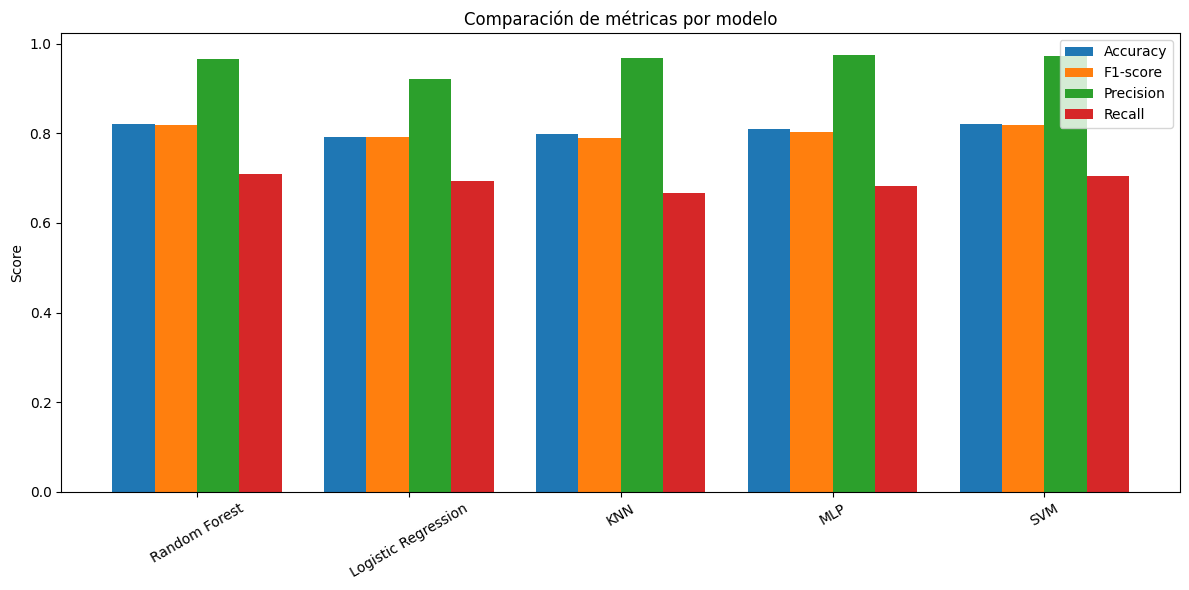

In [29]:
from sklearn.metrics import precision_score, recall_score

metrics = {
    'Accuracy': accuracies,
    'F1-score': f1_scores,
    
    'Precision': [precision_score(Y_test, pred) for pred in [rf_pred, lr_pred, knn_pred, mlp_pred, svm_pred]],
    'Recall': [recall_score(Y_test, pred) for pred in [rf_pred, lr_pred, knn_pred, mlp_pred, svm_pred]],
}

x = np.arange(len(model_names))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))
for i, (metric, values) in enumerate(metrics.items()):
    ax.bar(x + i*width - 1.5*width, values, width, label=metric)

ax.set_ylabel('Score')
ax.set_title('Comparación de métricas por modelo')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30)
ax.legend()
plt.tight_layout()
plt.show()